In [1]:
!pip install tensorflow

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, matthews_corrcoef, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/Shareddrives/Personal/UA&P/Year 4 Sem 2/Undergraduate Thesis/stock-prediction/test")

# Set plot style
sns.set_style('whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load data
ohlc_df = pd.read_csv('data/processed/ohlc_df.csv')

# Preprocessing
# Rename the first column to 'datetime' and convert to datetime objects
ohlc_df.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)
ohlc_df['datetime'] = pd.to_datetime(ohlc_df['datetime'])
ohlc_df.set_index('datetime', inplace=True)

train_size = int(len(ohlc_df) * 0.7)
val_size = int(len(ohlc_df) * 0.15)

SEQ_LENGTH = 60

train_indices = ohlc_df[:train_size].index
val_indices = ohlc_df[train_size - SEQ_LENGTH + 1:train_size + val_size].index
test_indices = ohlc_df[train_size + val_size - SEQ_LENGTH + 1:].index

PRED_HORIZON = 30

for close_col in [col for col in ohlc_df.columns if col.endswith('_close')]:
    ticker = close_col.split('_')[0]
    ohlc_df[f"{ticker}_log_return_1"] = (np.log(ohlc_df[close_col]) - np.log(ohlc_df[close_col].shift(1)))
    ohlc_df[f"{ticker}_log_return_10"] = (np.log(ohlc_df[close_col]) - np.log(ohlc_df[close_col].shift(10)))
    ohlc_df[f"{ticker}_log_return_30"] = (np.log(ohlc_df[close_col]) - np.log(ohlc_df[close_col].shift(30)))

    shifted_log_returns = ohlc_df[f"{ticker}_log_return_{PRED_HORIZON}"].shift(-PRED_HORIZON)

    thirds = ohlc_df.loc[train_indices, f"{ticker}_log_return_{PRED_HORIZON}"].quantile([1/3, 2/3])
    ohlc_df[f"{ticker}_fw_return_{PRED_HORIZON}_negative"] = (
        shifted_log_returns <= thirds[1/3]
    ).mask(shifted_log_returns.isna(), np.nan).astype(float)
    ohlc_df[f"{ticker}_fw_return_{PRED_HORIZON}_neutral"] = (
        (thirds[1/3] < shifted_log_returns) &
        (shifted_log_returns < thirds[2/3])
    ).mask(shifted_log_returns.isna(), np.nan).astype(float)
    ohlc_df[f"{ticker}_fw_return_{PRED_HORIZON}_positive"] = (
        thirds[2/3] <= shifted_log_returns
    ).mask(shifted_log_returns.isna(), np.nan).astype(float)

ohlc_df.dropna(inplace=True)

train_indices = train_indices[train_indices.isin(ohlc_df.index)]
test_indices = test_indices[test_indices.isin(ohlc_df.index)]

ohlc_df.drop(columns = [col for col in ohlc_df.columns if col.endswith('_perc_chg') or col.endswith('_net')], inplace=True)
target_cols = [col for col in ohlc_df.columns if "_fw_return_" in col]
feature_cols = [col for col in ohlc_df.columns if col not in target_cols]
features = ohlc_df[feature_cols].copy(deep=True)
targets = ohlc_df[target_cols].copy(deep=True)

print(f"Target Columns ({len(target_cols)}): {target_cols}")
print(f"Total Features: {len(feature_cols)}")

Target Columns (27): ['ac_fw_return_30_negative', 'ac_fw_return_30_neutral', 'ac_fw_return_30_positive', 'ali_fw_return_30_negative', 'ali_fw_return_30_neutral', 'ali_fw_return_30_positive', 'bdo_fw_return_30_negative', 'bdo_fw_return_30_neutral', 'bdo_fw_return_30_positive', 'bpi_fw_return_30_negative', 'bpi_fw_return_30_neutral', 'bpi_fw_return_30_positive', 'ict_fw_return_30_negative', 'ict_fw_return_30_neutral', 'ict_fw_return_30_positive', 'mbt_fw_return_30_negative', 'mbt_fw_return_30_neutral', 'mbt_fw_return_30_positive', 'mer_fw_return_30_negative', 'mer_fw_return_30_neutral', 'mer_fw_return_30_positive', 'sm_fw_return_30_negative', 'sm_fw_return_30_neutral', 'sm_fw_return_30_positive', 'smph_fw_return_30_negative', 'smph_fw_return_30_neutral', 'smph_fw_return_30_positive']
Total Features: 72


## Multi-Output Prediction
We are predicting all `perc_chg` variables simultaneously.

In [4]:
# 1. Split Data
X_train_df = features.loc[train_indices]
y_train_df = targets.loc[train_indices]
X_val_df = features.loc[val_indices]
y_val_df = targets.loc[val_indices]
X_test_df = features.loc[test_indices]
y_test_df = targets.loc[test_indices]

# 2. Scale Data
# Scaler for Features (X)
scaler_X = StandardScaler()

# Fit on train data

scaler_X.fit(X_train_df)

# Transform
X_train_scaled = scaler_X.transform(X_train_df)
X_val_scaled = scaler_X.transform(X_val_df)
X_test_scaled = scaler_X.transform(X_test_df)

print("Scalers fit complete.")

Scalers fit complete.


In [5]:
# Create sequences
def create_sequences(X_data, y_data, seq_length):
    X, y = [], []
    for i in range(len(X_data) - seq_length + 1):
        # Input Sequence: Steps [i] to [i + seq_length - 1]
        X.append(X_data[i:i + seq_length])
        # Target: Step [i + seq_length] ONLY (Single step prediction)
        y.append(y_data[i + seq_length - 1])
    return np.array(X), np.array(y)

X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []
for close_col in [col for col in ohlc_df.columns if col.endswith('_close')]:
    ticker = close_col.split('_')[0]
    ticker_features = [
        f'{ticker}_{f}' for f in [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "log_return_1",
            "log_return_10",
            "log_return_30"
        ]
    ]
    ticker_targets = [
        f'{ticker}_{f}' for f in [
            f"fw_return_{PRED_HORIZON}_negative",
            f"fw_return_{PRED_HORIZON}_neutral",
            f"fw_return_{PRED_HORIZON}_positive",
        ]
    ]

    X_train_segment, y_train_segment = create_sequences(
        X_train_scaled[:, features.columns.get_indexer(ticker_features)],
        y_train_df[ticker_targets].values,
        SEQ_LENGTH
    )
    X_val_segment, y_val_segment = create_sequences(
        X_val_scaled[:, features.columns.get_indexer(ticker_features)],
        y_val_df[ticker_targets].values,
        SEQ_LENGTH
    )
    X_test_segment, y_test_segment = create_sequences(
        X_test_scaled[:, features.columns.get_indexer(ticker_features)],
        y_test_df[ticker_targets].values,
        SEQ_LENGTH
    )

    X_train.append(X_train_segment)
    y_train.append(y_train_segment)
    X_val.append(X_val_segment)
    y_val.append(y_val_segment)
    X_test.append(X_test_segment)
    y_test.append(y_test_segment)

X_train, y_train = np.vstack(X_train), np.vstack(y_train)
X_val, y_val = np.vstack(X_val), np.vstack(y_val)
X_test, y_test = np.vstack(X_test), np.vstack(y_test)

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Validation shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")

Train shape: (412542, 60, 8), (412542, 3)
Validation shape: (88569, 60, 8), (88569, 3)
Test shape: (88308, 60, 8), (88308, 3)


## Build Multi-Output LSTM Model

In [20]:
n_outputs = y_train.shape[1]

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(3)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,883 (73.76 KB)

 Trainable params: 18,883 (73.76 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
train_tf_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).repeat().batch(128)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_tf_dataset,
    batch_size=128,
    steps_per_epoch=300,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2408 - val_loss: 0.2439
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2174 - val_loss: 0.2852
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2222 - val_loss: 0.2853
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2204 - val_loss: 0.3114
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2205 - val_loss: 0.2564
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2177 - val_loss: 0.2837
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2197 - val_loss: 0.2527
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2174 - val_loss: 0.2827
Epoch 9/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2168 - val_loss: 0.2325
Epoch 10/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2169 - val_loss: 0.2690
Epoch 11/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2154 - val_loss: 0.2281
Epoch 12/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 

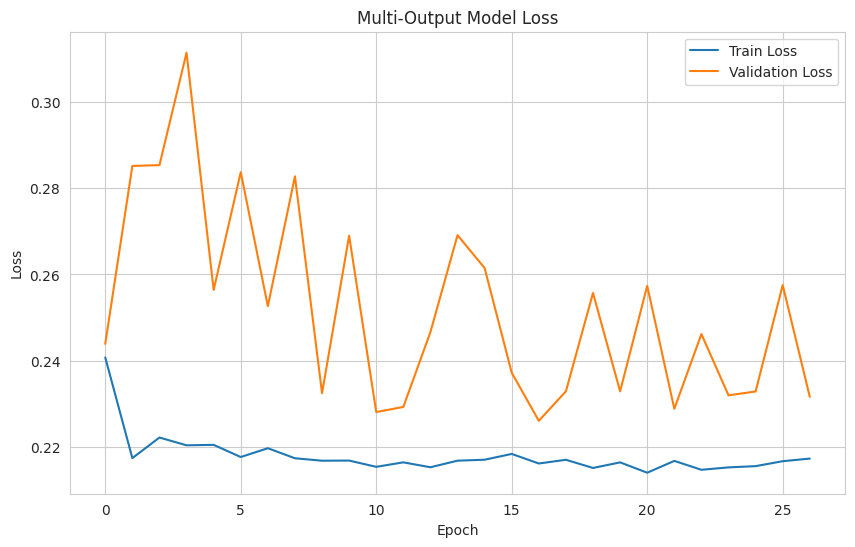

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Multi-Output Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluation
We evaluate average RMSE across all targets and visualize a few examples.

In [23]:
pred_probas = model.predict(X_test)

2760/2760 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [24]:
predictions = np.argmax(pred_probas, axis=1)
actual = np.argmax(y_test, axis=1)

print(classification_report(actual, predictions))

              precision    recall  f1-score   support

           0       0.42      0.27      0.33     32829
           1       0.37      0.10      0.16     23374
           2       0.37      0.70      0.48     32105

    accuracy                           0.38     88308
   macro avg       0.39      0.35      0.32     88308
weighted avg       0.39      0.38      0.34     88308



In [ ]:
# Plot the first target as an example (e.g., 'ac_perc_chg')
target_idx = 0
stock_name = target_cols[target_idx]

plt.figure(figsize=(16, 6))
plt.plot(inv_actual[:, target_idx], label=f'Actual {stock_name}', alpha=0.7)
plt.plot(inv_predictions[:, target_idx], label=f'Predicted {stock_name}', alpha=0.7)
plt.title(f'Prediction for {stock_name}')
plt.legend()
plt.show()

## Task-Conditioned Learning
We augment the data to train a single-output LSTM that can predict any stock given a task ID.

2025-12-27 12:01:19.490234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/fintech/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading data...
Adding volatility features...
Target Columns (9): ['ac_perc_chg', 'ali_perc_chg', 'bdo_perc_chg', 'bpi_perc_chg', 'ict_perc_chg', 'mbt_perc_chg', 'mer_perc_chg', 'sm_perc_chg', 'smph_perc_chg']
Total Features: 72
Scalers fit complete.
Train shape: (45853, 60, 72), (45853, 9)
Validation shape: (9778, 60, 72), (9778, 9)
Test shape: (9780, 60, 72), (9780, 9)
Initializing Data Generators...
Model Input Shape: (60, 81)


/opt/anaconda3/envs/fintech/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │       107,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,993 (613.25 KB)

 Trainable params: 156,993 (613.25 KB)

 Non-trainable params: 0 (0.00 B)

/opt/anaconda3/envs/fintech/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3225/3225 ━━━━━━━━━━━━━━━━━━━━ 825s 255ms/step - loss: 0.4536 - val_loss: 0.3947
Loss plot saved to task_model_loss.png
Evaluating...
Mean RMSE across all 9 stocks: 0.0016070022225033568
          Stock      RMSE
5  mbt_perc_chg  0.001165
7   sm_perc_chg  0.001178
3  bpi_perc_chg  0.001432
2  bdo_perc_chg  0.001489
6  mer_perc_chg  0.001527
Prediction plot saved to prediction_example.png


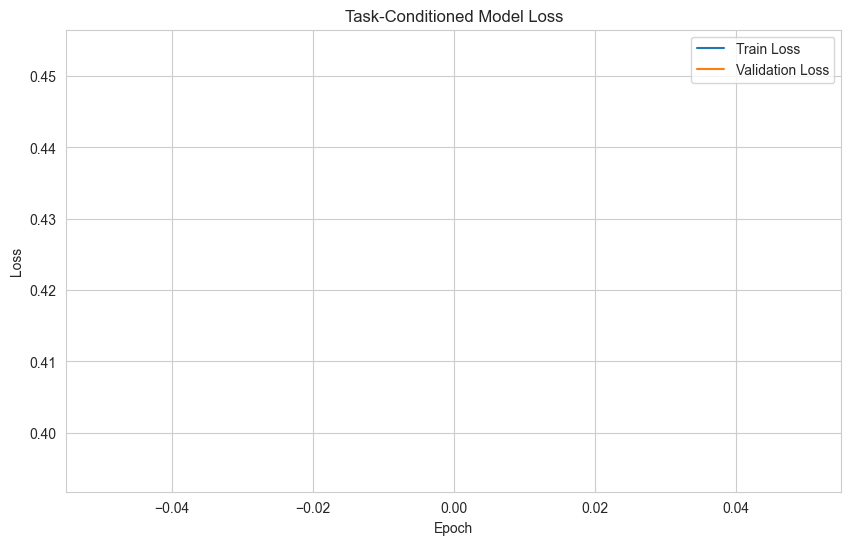

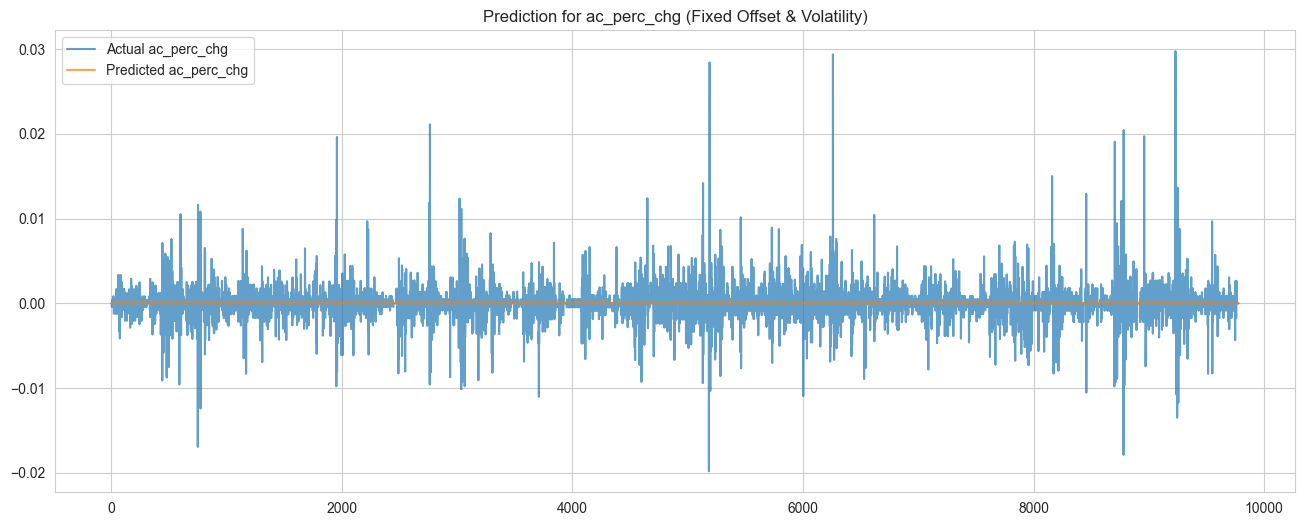

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

# Set plot style
sns.set_style('whitegrid')

# Load data
print("Loading data...")
ohlc_df = pd.read_csv('data/processed/ohlc_df.csv')

# Preprocessing
# Rename the first column to 'datetime' and convert to datetime objects
if 'Unnamed: 0' in ohlc_df.columns:
    ohlc_df.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)
ohlc_df['datetime'] = pd.to_datetime(ohlc_df['datetime'])
ohlc_df.set_index('datetime', inplace=True)

# Feature Engineering: Rolling Volatility (Fix for volatile periods)
print("Adding volatility features...")
qt = 20
for col in ohlc_df.columns:
    if col.endswith('_perc_chg'):
        # Calculate rolling standard deviation (volatility)
        stock_name = col.replace('_perc_chg', '')
        ohlc_df[f'{stock_name}_volatility'] = ohlc_df[col].rolling(window=qt).std()

# Clean data: Drop rows with NaNs
ohlc_df.dropna(inplace=True)

# Identify targets and features
target_cols = [col for col in ohlc_df.columns if col.endswith('_perc_chg')]
# Use all numeric columns as features (now includes volatility)
feature_cols = ohlc_df.columns.tolist()

print(f"Target Columns ({len(target_cols)}): {target_cols}")
print(f"Total Features: {len(feature_cols)}")

data = ohlc_df[feature_cols].copy()

# 1. Split Data
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.15)

train_df = data.iloc[:train_size]
val_df = data.iloc[train_size:train_size+val_size]
test_df = data.iloc[train_size+val_size:]

# 2. Scale Data
# Scaler for Features (X)
scaler_X = StandardScaler()
# Scaler for Targets (y)
# Fix for "offset from zero": Do not center the target (assume 0 mean for returns)
scaler_y = StandardScaler(with_mean=False)

# Fit on train data
X_train_raw = train_df.values
y_train_raw = train_df[target_cols].values

scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw)

# Transform
X_train_scaled = scaler_X.transform(train_df.values)
y_train_scaled = scaler_y.transform(train_df[target_cols].values)

X_val_scaled = scaler_X.transform(val_df.values)
y_val_scaled = scaler_y.transform(val_df[target_cols].values)

X_test_scaled = scaler_X.transform(test_df.values)
y_test_scaled = scaler_y.transform(test_df[target_cols].values)

print("Scalers fit complete.")

# Create sequences
def create_sequences(X_data, y_data, seq_length):
    X, y = [], []
    for i in range(len(X_data) - seq_length):
        # Input Sequence: Steps [i] to [i + seq_length - 1]
        X.append(X_data[i:i + seq_length])
        # Target: Step [i + seq_length] ONLY (Single step prediction)
        y.append(y_data[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Validation shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")

# Build Model (Task Conditioned approach from notebook)
# We augment the data to train a single-output LSTM that can predict any stock given a task ID.

# Optimize Data Creation using a Generator to satisfy memory constraints
class TaskDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X_data, y_data, batch_size=128, shuffle=True):
        self.X_data = X_data
        self.y_data = y_data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_samples, self.seq_length, self.n_features = X_data.shape
        self.n_stocks = y_data.shape[1]
        self.indexes = np.arange(self.n_samples * self.n_stocks)

    def __len__(self):
        return int(np.ceil(len(self.indexes) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X = np.zeros((len(batch_indexes), self.seq_length, self.n_features + self.n_stocks))
        y = np.zeros((len(batch_indexes)))

        for i, idx_val in enumerate(batch_indexes):
            sample_idx = idx_val // self.n_stocks
            stock_idx = idx_val % self.n_stocks
            X[i, :, :self.n_features] = self.X_data[sample_idx]
            X[i, :, self.n_features + stock_idx] = 1.0
            y[i] = self.y_data[sample_idx, stock_idx]

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

print("Initializing Data Generators...")
train_gen = TaskDataGenerator(X_train, y_train, batch_size=128, shuffle=True)
val_gen = TaskDataGenerator(X_val, y_val, batch_size=128, shuffle=False)

# Determine input shape from data
n_features = X_train.shape[2]
n_stocks = y_train.shape[1]
input_shape = (SEQ_LENGTH, n_features + n_stocks)

print(f"Model Input Shape: {input_shape}")

# Model
# Remove Dropout to allow model to overfit/learn noise better
model_task = Sequential([
    LSTM(128, return_sequences=True, input_shape=input_shape),
    LSTM(64, return_sequences=False),
    Dense(1) # Single output
])

model_task.compile(optimizer='adam', loss='mean_absolute_error')
model_task.summary()

# Train
history_task = model_task.fit(
    train_gen,
    epochs=1, 
    validation_data=val_gen,
    verbose=1
)

# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(history_task.history['loss'], label='Train Loss')
plt.plot(history_task.history['val_loss'], label='Validation Loss')
plt.title('Task-Conditioned Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('task_model_loss.png')
print("Loss plot saved to task_model_loss.png")

# Evaluation
print("Evaluating...")
# Predictions are done per-stock below to avoid memory issues
# predictions_task = model_task.predict(X_test_task) # Removed to save memory

# We need to reshape predictions back to (n_samples, n_stocks) to compare effectively
# OR we evaluate on the long form.
# The user's notebook did inverse transform.
# Since we mixed everything, inverse transform is tricky unless we know which prediction belongs to which stock.
# BUTscaler_y fits on all columns. if we transform a single column, it expects shape (n, n_stocks).
# Actually scaler_y expects (n, n_stocks).
# We can't inverse transform the 1D array directly if we want to separate stocks.

# Let's perform per-stock evaluation using the un-shuffled test set logic
n_stocks = len(target_cols)
n_test_samples = X_test.shape[0]

# Pre-allocate array for all predictions
all_preds = np.zeros((n_test_samples, n_stocks))

for stock_idx in range(n_stocks):
    # Prepare input for this stock
    X_copy = X_test.copy()
    task_encoding = np.zeros((n_test_samples, SEQ_LENGTH, n_stocks))
    task_encoding[:, :, stock_idx] = 1.0
    X_cond = np.concatenate([X_copy, task_encoding], axis=2)
    
    # Predict
    preds = model_task.predict(X_cond, verbose=0)
    all_preds[:, stock_idx] = preds.flatten()

# Inverse transform
inv_predictions = scaler_y.inverse_transform(all_preds)
inv_actual = scaler_y.inverse_transform(y_test)

# Calculate RMSE
rmse_per_col = np.sqrt(np.mean((inv_actual - inv_predictions)**2, axis=0))
mean_rmse = np.mean(rmse_per_col)

print(f"Mean RMSE across all {len(target_cols)} stocks: {mean_rmse}")
results_df = pd.DataFrame({'Stock': target_cols, 'RMSE': rmse_per_col})
print(results_df.sort_values('RMSE').head())

# Plot Example
target_idx = 0
stock_name = target_cols[target_idx]

plt.figure(figsize=(16, 6))
plt.plot(inv_actual[:, target_idx], label=f'Actual {stock_name}', alpha=0.7)
plt.plot(inv_predictions[:, target_idx], label=f'Predicted {stock_name}', alpha=0.7)
plt.title(f'Prediction for {stock_name} (Fixed Offset & Volatility)')
plt.legend()
plt.savefig('prediction_example.png')
print("Prediction plot saved to prediction_example.png")


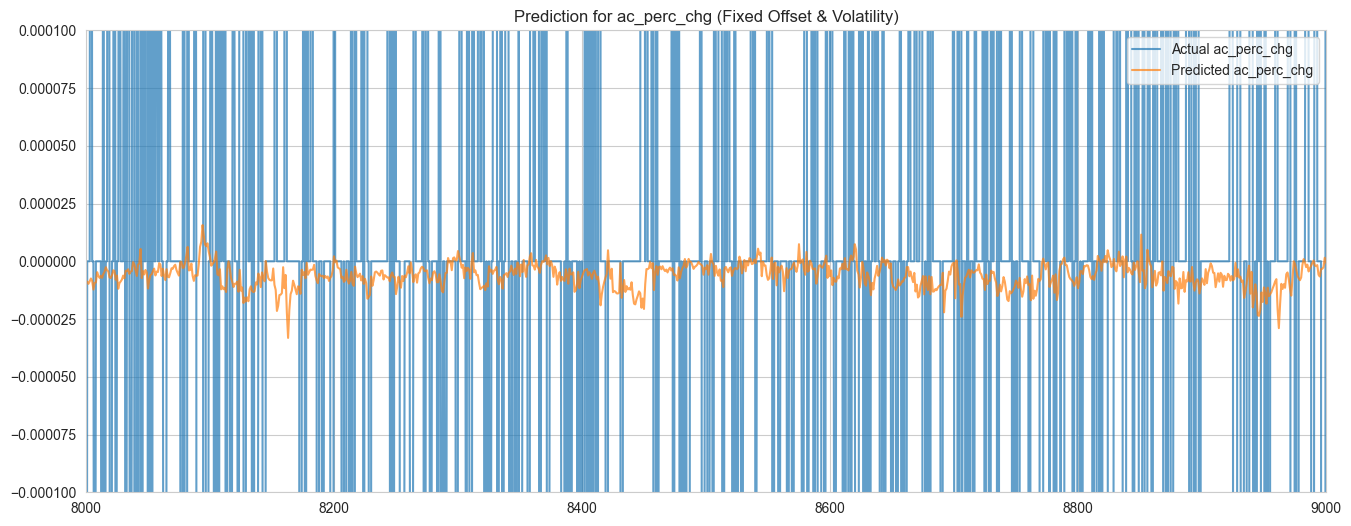

Prediction plot saved to prediction_example.png


In [ ]:
# Plot Example
target_idx = 0
stock_name = target_cols[target_idx]

plt.figure(figsize=(16, 6))
plt.plot(inv_actual[:, target_idx], label=f'Actual {stock_name}', alpha=0.7)
plt.plot(inv_predictions[:, target_idx], label=f'Predicted {stock_name}', alpha=0.7)
plt.title(f'Prediction for {stock_name} (Fixed Offset & Volatility)')
plt.legend()
plt.xlim((8000, 9000))
plt.ylim((-0.0001, 0.0001))
plt.show()
print("Prediction plot saved to prediction_example.png")

In [ ]:
# Custom Callback to check loss every N batches
class BatchValidationCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, batch_interval=10):
        super().__init__()
        self.val_data = val_data
        self.batch_interval = batch_interval
        self.batch_losses = []

    def on_train_batch_end(self, batch, logs=None):
        # 'batch' is the index relative to the start of the epoch
        if (batch + 1) % self.batch_interval == 0:
            # Calculate loss on a sample of valid set (to be fast) or full valid set
            # Here we use full val set
            val_loss = self.model.evaluate(self.val_data[0], self.val_data[1], verbose=0)
            self.batch_losses.append(val_loss)
            print(f" - batch {batch+1} val_loss: {val_loss:.4f}")


BATCH_SIZE = 128
steps_per_epoch = X_train_task.shape[0] // BATCH_SIZE
check_interval = max(1, steps_per_epoch // 5) # Check 5 times per epoch

batch_valid_callback = BatchValidationCallback(
    val_data=(X_val_task, y_val_task),
    batch_interval=check_interval
)

history_task = model_task.fit(
    X_train_task, y_train_task,
    batch_size=BATCH_SIZE,
    epochs=4,
    validation_data=(X_val_task, y_val_task),
    callbacks=[batch_valid_callback],
    verbose=1
)

Epoch 1/4
 626/3230 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.0052 - batch 645 val_loss: 0.6660
1275/3230 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.8940 - batch 1290 val_loss: 0.6654
1934/3230 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.8495 - batch 1935 val_loss: 0.6704
2568/3230 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.8305 - batch 2580 val_loss: 0.6656
3220/3230 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8152 - batch 3225 val_loss: 0.6656
3230/3230 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.6673 - val_loss: 0.6658
Epoch 2/4
 638/3230 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.9810 - batch 645 val_loss: 0.6652
1276/3230 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.8792 - batch 1290 val_loss: 0.6740
1922/3230 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.8405 - batch 1935 val_loss: 0.6630
2579/3230 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.8181 - batch 2580 val_loss: 0.6627
3212/3230 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8100 - batch 3225 val_loss: 0.6731
3230/3230 ━━━━━━━━━━━━

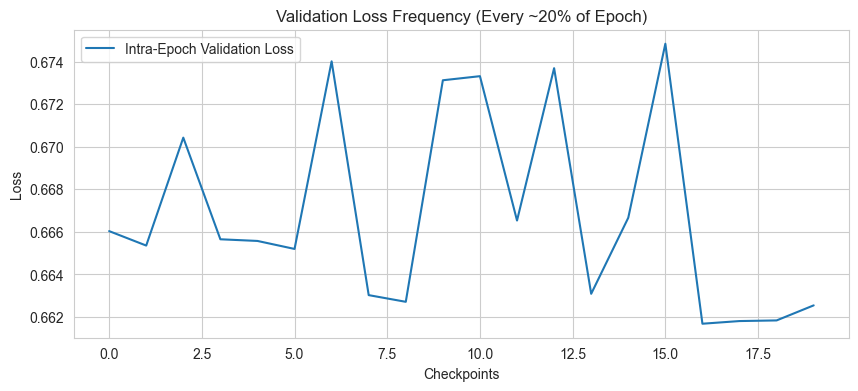

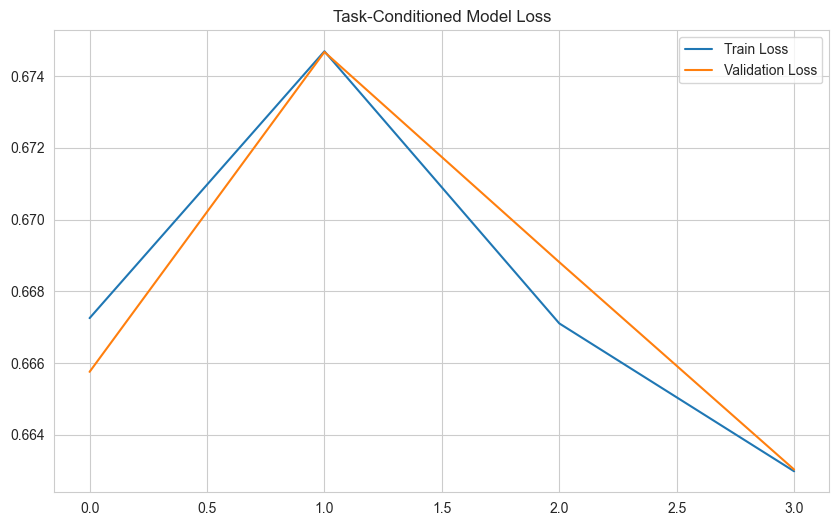

In [ ]:
# Plot Intra-Epoch Validation Loss
plt.figure(figsize=(10, 4))
plt.plot(batch_valid_callback.batch_losses, label='Intra-Epoch Validation Loss')
plt.title('Validation Loss Frequency (Every ~20% of Epoch)')
plt.xlabel('Checkpoints')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Standard history plot
plt.figure(figsize=(10, 6))
plt.plot(history_task.history['loss'], label='Train Loss')
plt.plot(history_task.history['val_loss'], label='Validation Loss')
plt.title('Task-Conditioned Model Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_task = model_task.predict(X_test_task)

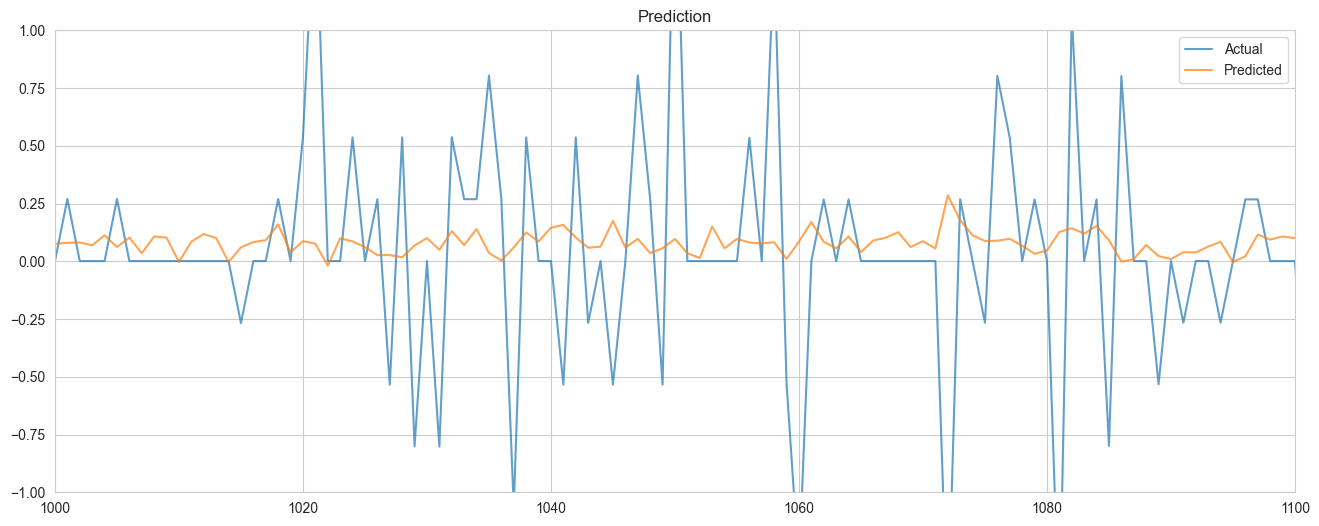

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(y_test_task, label='Actual', alpha=0.7)
plt.plot(y_pred_task, label='Predicted', alpha=0.7)
plt.title(f'Prediction')
plt.legend()
plt.xlim((1000, 1100))
plt.ylim((-1, 1))
plt.show()

# Hard Parameter Sharing Model

Loading data...
Data Loaded. Shape: (65610, 63)
Creating Time & volatility features...
Identified 9 stocks.


/var/folders/vf/nl78hts112z4fbgl93t713_h0000gn/T/ipykernel_5282/1899570436.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=all_labels_flat, palette='viridis')


Saved class distribution plot to: class_distribution.png
Total Features: 78, Total Stocks: 9
Target shapes: train=(45913, 9, 3), val=(9838, 9, 3), test=(9840, 9, 3)
Creating sequences...
Calculating sample weights...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 78)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │       105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         1,755 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 9, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 9, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

717/717 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.4340 - loss: 1.8091 - val_accuracy: 0.3464 - val_loss: 1.8062
Epoch 4/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4328 - loss: 1.7986

717/717 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.4358 - loss: 1.7947 - val_accuracy: 0.3920 - val_loss: 1.7910
Epoch 5/30
716/717 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4396 - loss: 1.7871

717/717 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.4418 - loss: 1.7836 - val_accuracy: 0.3863 - val_loss: 1.7866
Epoch 6/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 94s 131ms/step - accuracy: 0.4440 - loss: 1.7752 - val_accuracy: 0.3429 - val_loss: 1.7912
Epoch 7/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.4483 - loss: 1.7667 - val_accuracy: 0.3613 - val_loss: 1.7935


Loading best model from checkpoint...
Evaluating Classification Performance...
306/306 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step

Global Classification Report:
              precision    recall  f1-score   support

    Negative       0.26      0.40      0.31     19064
     Neutral       0.68      0.35      0.46     49696
    Positive       0.28      0.48      0.35     19260

    accuracy                           0.39     88020
   macro avg       0.41      0.41      0.38     88020
weighted avg       0.50      0.39      0.41     88020


Global Confusion Matrix:
Saved Confusion Matrix to: confusion_matrix.png


KeyError: 'pr_auc'

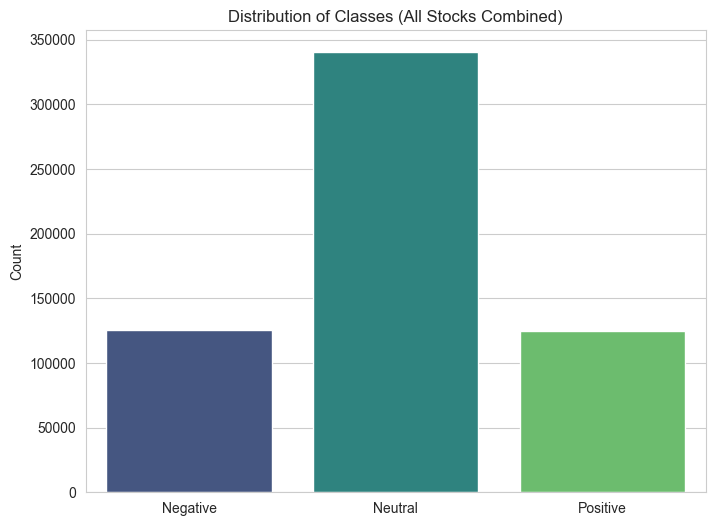

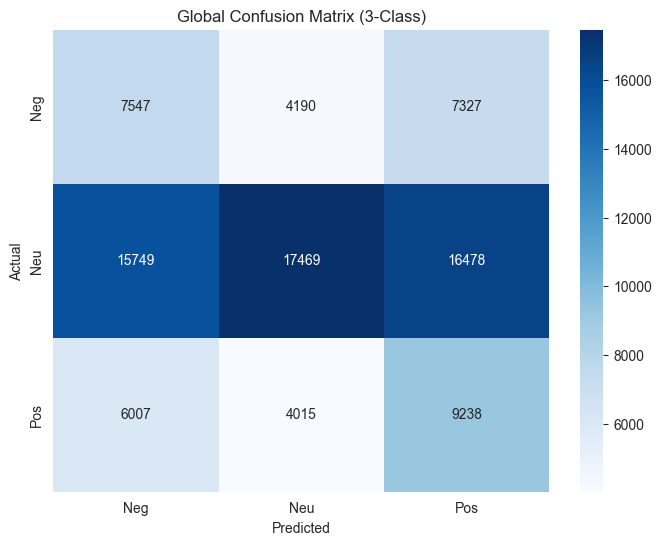

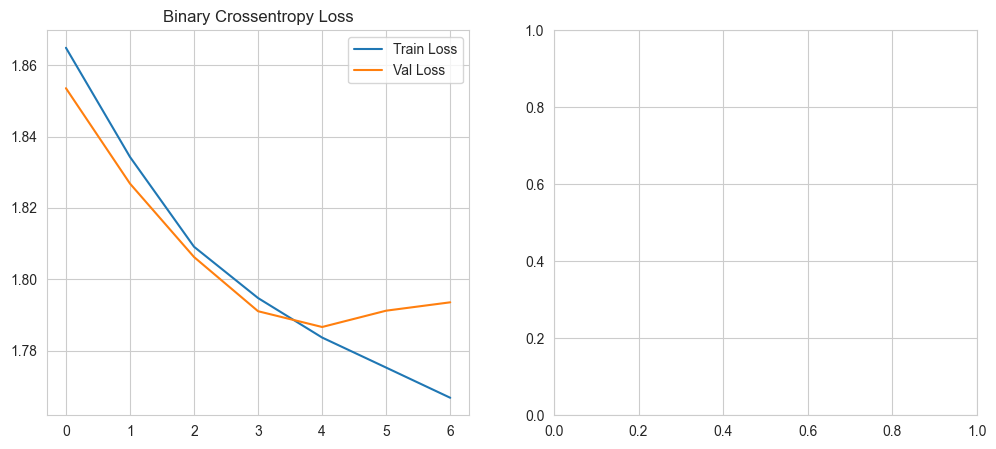

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Reshape, Softmax
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import os

# -----------------------------------------------------------------------------
# 1. Configuration & Setup
# -----------------------------------------------------------------------------
sns.set_style('whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

DATA_PATH = 'test/data/processed/ohlc_df.csv'
SEQ_LENGTH = 60
BATCH_SIZE = 64
EPOCHS = 30 
EPS = 0
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

# -----------------------------------------------------------------------------
# 2. Data Loading & Preprocessing
# -----------------------------------------------------------------------------
print("Loading data...")
if not os.path.exists(DATA_PATH):
    # Fallback for different execution contexts
    DATA_PATH = 'data/processed/ohlc_df.csv'

df = pd.read_csv(DATA_PATH)

# Handle datetime
if 'Unnamed: 0' in df.columns:
    df.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Drop rows with NaNs immediately
df.dropna(inplace=True)

print(f"Data Loaded. Shape: {df.shape}")

# -----------------------------------------------------------------------------
# 3. Feature Engineering
# -----------------------------------------------------------------------------
print("Creating Time & volatility features...")

stock_prefixes = set([c.split('_')[0] for c in df.columns if '_' in c])
print(f"Identified {len(stock_prefixes)} stocks.")

# 3.1 Time Features
df['hour'] = df.index.hour
df['minute'] = df.index.minute
df['dayofweek'] = df.index.dayofweek

# 3.2 Market Phases (Vectorized)
t_min = df['hour'] * 60 + df['minute']
df['flag_open'] = ((t_min >= 570) & (t_min <= 585)).astype(int)
df['flag_recess'] = (((t_min >= 690) & (t_min <= 720)) | ((t_min >= 780) & (t_min <= 810))).astype(int)
df['flag_close'] = ((t_min >= 870) & (t_min <= 900)).astype(int)

# 3.3 Volatility Features
for prefix in stock_prefixes:
    col = f'{prefix}_perc_chg'
    if col in df.columns:
        df[f'{prefix}_volatility'] = df[col].rolling(window=20).std()

df.dropna(inplace=True)

# -----------------------------------------------------------------------------
# 4. Classification Targets & Feature Definition
# -----------------------------------------------------------------------------
# Targets: Direction indicators (1 if > 0, 0 otherwise)
target_cols = [c for c in df.columns if c.endswith('_perc_chg')]
n_stocks = len(target_cols)

# Create 3-class labels: 0=Negative, 1=Neutral, 2=Positive
label_cols = []
all_labels_flat = []
for col in target_cols:
    label_name = col.replace('_perc_chg', '_class')
    
    # 0: Neg ( < -EPS ), 1: Neu ( abs <= EPS ), 2: Pos ( > EPS )
    df[label_name] = 1 # Default to Neutral
    df.loc[df[col] < -EPS, label_name] = 0
    df.loc[df[col] > EPS, label_name] = 2
    
    label_cols.append(label_name)
    all_labels_flat.extend(df[label_name].values)

# --- Visualization of Class Distribution ---
plt.figure(figsize=(8, 6))
sns.countplot(x=all_labels_flat, palette='viridis')
plt.title('Distribution of Classes (All Stocks Combined)')
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.ylabel('Count')
plt.savefig('class_distribution.png')
print("Saved class distribution plot to: class_distribution.png")

# Features: All numeric columns (excluding labels)
feature_cols = [c for c in df.columns if not c.endswith('_class')]
print(f"Total Features: {len(feature_cols)}, Total Stocks: {n_stocks}")

# -----------------------------------------------------------------------------
# 5. Split & Scale
# -----------------------------------------------------------------------------
train_size = int(len(df) * (1 - TEST_SPLIT - VAL_SPLIT))
val_size = int(len(df) * VAL_SPLIT)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

# Scaler for Features
scaler_X = StandardScaler()
scaler_X.fit(train_df[feature_cols].values)

X_train = scaler_X.transform(train_df[feature_cols].values)
X_val = scaler_X.transform(val_df[feature_cols].values)
X_test = scaler_X.transform(test_df[feature_cols].values)

# Targets (One-hot encode each stock's labels)
# y data currently has shape (N, n_stocks) with values 0, 1, 2
y_train_raw = train_df[label_cols].values
y_val_raw = val_df[label_cols].values
y_test_raw = test_df[label_cols].values

def one_hot_multi_output(y_array, num_classes=3):
    # Input y_array shape: (N, n_stocks)
    # Output shape: (N, n_stocks, num_classes)
    N, n_s = y_array.shape
    y_oh = np.zeros((N, n_s, num_classes))
    for i in range(n_s):
        y_oh[:, i, :] = to_categorical(y_array[:, i], num_classes=num_classes)
    return y_oh

y_train = one_hot_multi_output(y_train_raw)
y_val = one_hot_multi_output(y_val_raw)
y_test = one_hot_multi_output(y_test_raw)

print(f"Target shapes: train={y_train.shape}, val={y_val.shape}, test={y_test.shape}")

# -----------------------------------------------------------------------------
# 6. Sequence Creation
# -----------------------------------------------------------------------------
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Creating sequences...")
X_train_seq, y_train_seq = create_dataset(X_train, y_train, SEQ_LENGTH)
X_val_seq, y_val_seq = create_dataset(X_val, y_val, SEQ_LENGTH)
X_test_seq, y_test_seq = create_dataset(X_test, y_test, SEQ_LENGTH)

# 6.1 Create Sample Weights for Imbalance (0:1, 1:4)
# Since this is multi-label (n_stocks outputs in one layer), 
# we calculate a per-sample weight by averaging the weights of all labels in that sample.
def get_sample_weights(y):
    # y shape: (N, n_stocks, 3)
    # Based on provided distribution: Pos=21%, Neu=57%, Neg=21%
    # Inverse frequency weights: Neg=1/0.21, Neu=1/0.57, Pos=1/0.21
    # Normalized weights (Neu=1.0): Neg=2.71, Neu=1.0, Pos=2.71
    y_classes = np.argmax(y, axis=-1)
    
    weights_matrix = np.ones_like(y_classes, dtype=float)
    weights_matrix[y_classes == 0] = 2.71 # Negative
    weights_matrix[y_classes == 1] = 1.00 # Neutral
    weights_matrix[y_classes == 2] = 2.71 # Positive
    
    return weights_matrix

print("Calculating sample weights...")
train_weights = get_sample_weights(y_train_seq)
# We usually don't weight validation for "purity" of metrics, 
# but we can apply it to loss if we want it to be comparable.
val_weights = get_sample_weights(y_val_seq)

# -----------------------------------------------------------------------------
# 7. Model Building (Hard Parameter Sharing for Classification)
# -----------------------------------------------------------------------------
input_layer = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))

# Shared LSTM Bottom
x = LSTM(128, return_sequences=True)(input_layer)
x = Dropout(0.2)(x) 
x = LSTM(64, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Shared Representation
x = Dense(64, activation='relu')(x)

# Multi-class Output: n_stocks * 3 neurons, reshaped to (n_stocks, 3)
x = Dense(n_stocks * 3)(x)
x = Reshape((n_stocks, 3))(x)
output_layer = Softmax(axis=-1)(x)

model = Model(inputs=input_layer, outputs=output_layer)

# Optimizer & Loss
# Using Categorical Crossentropy for multi-output classification
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

# -----------------------------------------------------------------------------
# 8. Training & Callbacks
# -----------------------------------------------------------------------------
print("Starting Training (Classification)...")

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    mode='min'
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    'best_model_classification.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

history = model.fit(
    X_train_seq, y_train_seq,
    sample_weight=train_weights,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val_seq, val_weights),
    shuffle=True,
    callbacks=[early_stopping, checkpoint],  # Added Callbacks
    verbose=1
)

# Load the best model specifically (in case restore_best_weights isn't used or for explicit safety)
if os.path.exists('best_model_classification.h5'):
    print("Loading best model from checkpoint...")
    model = tf.keras.models.load_model('best_model_classification.h5')

# -----------------------------------------------------------------------------
# 9. Evaluation
# -----------------------------------------------------------------------------
print("Evaluating Classification Performance...")

y_prob = model.predict(X_test_seq)
# y_prob shape: (N, n_stocks, 3)
y_pred = np.argmax(y_prob, axis=-1)
y_true = np.argmax(y_test_seq, axis=-1)

# Flatten everything for global report
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

print("\nGlobal Classification Report:")
print(classification_report(y_true_flat, y_pred_flat, target_names=['Negative', 'Neutral', 'Positive']))

print("\nGlobal Confusion Matrix:")
cm = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Global Confusion Matrix (3-Class)')
plt.savefig('confusion_matrix.png')
print("Saved Confusion Matrix to: confusion_matrix.png")

# -----------------------------------------------------------------------------
# 10. Visualization
# -----------------------------------------------------------------------------
# Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Binary Crossentropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['pr_auc'], label='Train PR-AUC')
plt.plot(history.history['val_pr_auc'], label='Val PR-AUC')
plt.title('Precision-Recall AUC')
plt.legend()
plt.tight_layout()
plt.savefig('classification_history.png')

# Confidence Distribution for a sample stock (Neutral class)
stock_idx = 0
plt.figure(figsize=(10, 6))
sns.histplot(y_prob[:, stock_idx, 1], bins=50, kde=True, color='gray', label='Neutral Prob')
sns.histplot(y_prob[:, stock_idx, 2], bins=50, kde=True, color='green', label='Positive Prob')
sns.histplot(y_prob[:, stock_idx, 0], bins=50, kde=True, color='red', label='Negative Prob')
plt.title(f'Prediction Confidence Distribution: {label_cols[stock_idx]}')
plt.xlabel('Probability')
plt.legend()
plt.savefig('confidence_distribution.png')

print("Saved plots: classification_history.png, confidence_distribution.png")


In [ ]:
for i, stock in enumerate(label_cols):
    acc = classification_report(y_test_seq[:, i], y_pred[:, i])
    print(acc)

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets